# Multi-objective version of the Lake Problem

This notebook implements a stochastic, multi-objective optimization of P discharges from a wastewater treatment plant to maximize discounted economic benefits and the probability of the lake P threshold staying below the critical P threshold beyond which the lake is irreversibly eutrophic:

\begin{align}
\text{Minimize: } &[-O_1, O_2]\\
&O_1 = \mathbb{E}\Bigg[\sum_{t=1}^T \delta^t a_{t}\Bigg]\\
&O_2 = \mathbb{E}\Bigg[\frac{1}{T} \sum_{t=1}^T X_{t}\Bigg]\\
\text{s.t. } &P(X_t < X^{crit}) \geq 0.85
\end{align}

where  
* $a_t$ = anthropogenic P discharge at time $t$  
* $X_t$ = P concentration in the lake at time $t$

The P concentration in the lake can be described by the following equation (Carpenter et al., 1999):

$X_{t+1} = X_t + \frac{X_t^q}{1+X_t^q} - bX_t + a_t + Y_t$

where  
* $q$ = sigmoid P recycling rate from sediment
* $b$ = linear P loss rate from outflow
* $Y_t\sim LN(\mu,\sigma^2)$ = random natural P inflow  at time $t$

The mean and probability in the objective function are estimated empirically across $N=100$ simulations (ensemble members) of $T=100$ years. Anthropogenic emissions are optimized using direct policy search following Quinn et al. (2017).

<ins>References</ins>:  

Carpenter, S. R., Ludwig, D., & Brock, W. A. (1999). Management of eutrophication for lakes subject to potentially irreversible change. Ecological applications, 9(3), 751-771.

Quinn, J. D., Reed, P. M., & Keller, K. (2017). Direct policy search for robust multi-objective management of deeply uncertain socio-ecological tipping points. Environmental modelling & software, 92, 125-141.

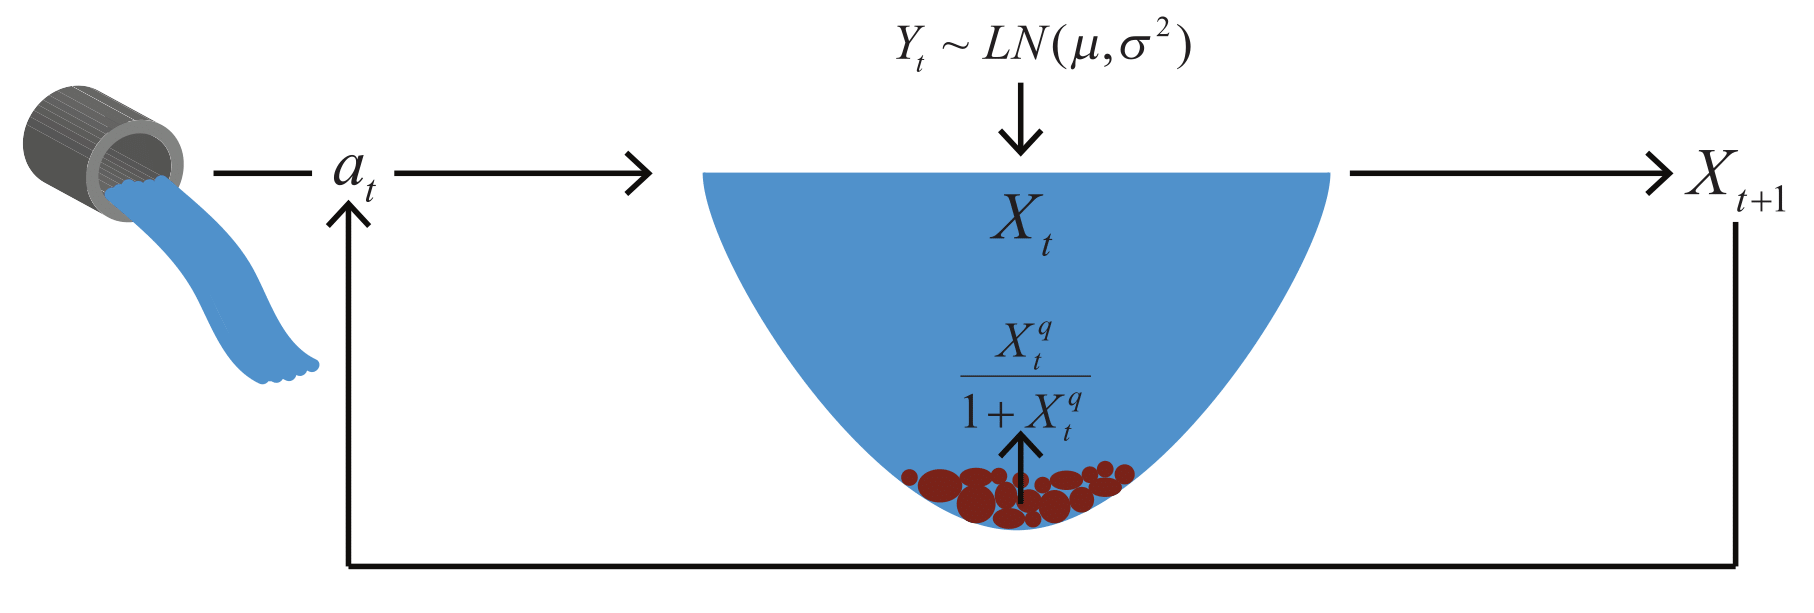

In [1]:
!pip install platypus-opt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 4.6 MB/s eta 0:00:00


In [2]:
# Python implementation of a 2-objective version of the lake problem
# using Direct Policy Search, optimized by NSGA-II

# Lake parameters
# b    : proportion of phosphorous lost from the lake each year;
# q    : steepness of the sigmoid curve, large values give a steeper slope;

# Parameters related to utiltiy
# delta : discount rate, set at 0.98

# Lake state variabiles
# X : phosphorous concentration in the lake at a given time step;
# initially set to 0

# Stochasticity is introduced by natural variability around anthropogenic pollution flow,
# which is generated form a log-normal distribution

# T : the time horizon for planning (100 years in this example)

# Decision variable
# vars : vector of length 3n describing the policy parameters
# n is the number of RBFs, each with a weight, center and radius
# format of vars is [c1, b1, w1, c2, b2, w2, ..., cn, bn, wn]
# all variables must be between 0 and 1, and all weights must sum to 1
# The weights determined by Borg aren't constrained to sum to 1,
# but are normalized to do so in the model simulation
# The actual decision, the amount of pollution emitted by the town, is Y,
# a function of vars and the current state of the lake (lake_state)

# Objectives
# 1: average discounted net benefit
# 2: average reliability

# Constraints
# Reliability must be > 85%

import numpy as np
from scipy.optimize import root
import scipy.stats as ss
from platypus import NSGAII, Problem, Real, nondominated, unique
import matplotlib.pyplot as plt

def LakeModel_DPS(vars, seed=123, b=0.42, q=2.0, mean=0.03, std=np.sqrt(10**(-5)), \
  delta=0.98, X0=0, opt=True):
  '''
  b = linear P removal rate
  q = sigmoid P recycling rate
  mean = real-space mean of log-normally distributed non-point source pollution
  std = real-space standard deviation of log-normally distributed non-point source pollution
  delta = discount parameter
  X0 = initial lake P concentration
  '''
  # Compute Pcrit given b and q
  def fun(x):
    return [(x[0]**q)/(1+x[0]**q) - b*x[0]]
  soln = root(fun, 0.75)
  Pcrit = soln.x

  # Initialize arrays to store objective function values and constraints
  objs = [0.0]*nobjs
  constrs = [0.0]*nconstrs

  # Set log-space inflow distribution parameters
  log_std = np.sqrt(np.log(1+std**2/mean**2))
  log_mean = np.log(mean) - 0.5*(log_std**2)

  # Initialize arrays to store discounted economic benefits and reliability of staying below Pcrit
  discounted_benefit = np.zeros([N])
  yrs_Pcrit_met = np.zeros([N])

  # initialize arrays to store P concentrations (X) and anthropogenic P emissions (a)
  X = np.zeros([N,T+1])
  a = np.zeros([N,T])

  # Randomly generate N ensemble members of T years of natural P inflows
  Y = np.zeros([N,T])
  for i in range(N):
    np.random.seed(seed+i)
    Y[i,:] = np.exp(ss.norm.rvs(log_mean, log_std, T))

  # Determine centers, radii and weights of RBFs
  C = vars[0::3]
  R = vars[1::3]
  W = vars[2::3]
  newW = np.zeros(len(W))

  # Normalize weights to sum to 1
  total = sum(W)
  if total != 0.0:
    for j in range(len(W)):
      newW[j] = W[j]/total
  else: # all weights equal
    for j in range(len(W)):
      newW[j] = 1/n

  # Run lake model simulation
  for i in range(N):
    X[i,0] = X0
    #find policy-derived emission
    a[i,0] = RBFpolicy(X[i,0], C, R, newW)

    for t in range(T):
      X[i,t+1] = X[i,t]*(1-b) + (X[i,t]**q)/(1+(X[i,t]**q)) + a[i,t] + Y[i,t]
      discounted_benefit[i] = discounted_benefit[i] + a[i,t]*delta**t

      if X[i,t+1] < Pcrit:
        yrs_Pcrit_met[i] = yrs_Pcrit_met[i] + 1

      if t<(T-1):
        #find policy-derived emission
        a[i,t+1] = RBFpolicy(X[i,t+1], C, R, newW)

  # Calculate minimization objectives (defined in comments at beginning of file)
  objs[0] = -np.mean(discounted_benefit) # average economic benefit, negate for minimization
  objs[1] = np.mean(X) # average P concentration

  # constraint: reliability_threshold - reliability <= 0
  reliability = np.sum(yrs_Pcrit_met)/(T*N) #average P concentration
  constrs[0] = max(0.0, reliability_threshold - reliability)

  if opt:
    return (objs, constrs)
  else:
    return X, a

def RBFpolicy(x, C, R, W):
    # Determine pollution emission decision, Y
    a = 0
    for j in range(len(C)):
        if R[j] != 0:
            a = a + W[j]*((np.absolute(x-C[j])/R[j])**3)

    a = min(0.1,max(a,0.01))

    return a

In [3]:
# Set the number of RBFs (n), decision variables, objectives and constraints
n = 2
nvars = 3*n
nobjs = 2
nconstrs = 1

# Set global lake model parameters
alpha = 0.4 # benefit per unit P emitted
T = 100 # number of years simulated
N = 100 # number of ensemble members
reliability_threshold = 0.85

# set up problem for multi-objective optimization with Platypus using NSGAII
problem = Problem(nvars, nobjs, nconstrs)
problem.types[:] = [Real(-2,2), Real(0,2), Real(0,1)]*n # bounds on [center, radius, weight]*n RBFs
problem.function = LakeModel_DPS

algorithm = NSGAII(problem)
algorithm.run(1000)

In [4]:
# Reformat results into arrays of decision variables and objectives:
nsolns = len(unique(nondominated(algorithm.result)))
bestVars = np.zeros([nsolns,nvars])
bestObjs = np.zeros([nsolns,nobjs])
for i, solution in enumerate(unique(nondominated(algorithm.result))):
  bestVars[i,:] = solution.variables
  bestObjs[i,:] = solution.objectives

Plot the Pareto front.

Text(0, 0.5, 'Average Phosphorus Concentration')

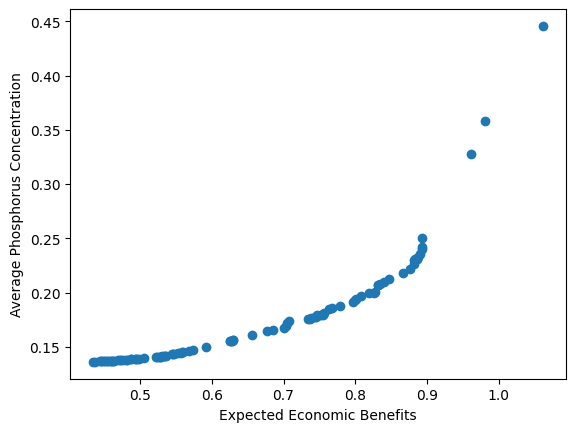

In [5]:
fig = plt.figure(111)

ax = fig.add_subplot(111)
ax.scatter(-bestObjs[:,0],bestObjs[:,1], color="tab:blue")
ax.set_xlabel("Expected Economic Benefits")
ax.set_ylabel("Average Phosphorus Concentration")

Compare the benefits-maximizing policy rule with the phosphorus-minimizing policy rule and a compromise rule (closest to the ideal point in Euclidean distance).

Text(0, 0.5, '$a_t$')

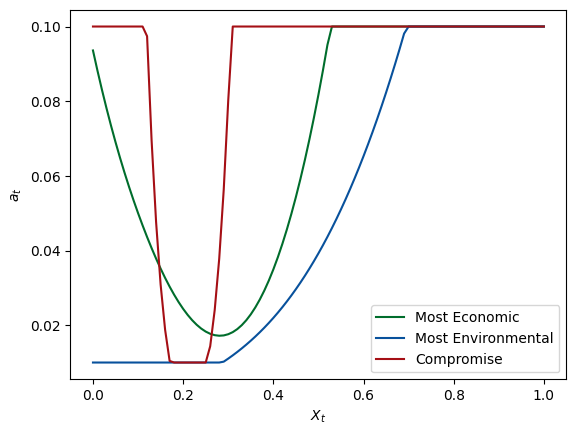

In [6]:
# find best solution on each objective and best compromise
bestObj1 = np.argmin(bestObjs[:,0])
bestObj2 = np.argmin(bestObjs[:,1])
distIdeal = ((bestObjs[:,0]-np.min(bestObjs[:,0]))/np.min(bestObjs[:,0]))**2 + \
 ((bestObjs[:,1]-np.min(bestObjs[:,1]))/np.min(bestObjs[:,1]))**2
bestCompromise = np.argmin(distIdeal)
bestPolicies = [bestObj1, bestObj2, bestCompromise]

# colors for select policies
light_colors = ["#74c476", "#6baed6", "#fb6a4a"]
medium_colors = ["#31a354","#3182bd","#de2d26"]
dark_colors = ["#006d2c","#08519c","#a50f15"]
labels = ["Most Economic","Most Environmental","Compromise"]
fig = plt.figure()
ax = fig.add_subplot(111)
x = np.arange(0,1.01,0.01)

def getDischarge(vars, x):
  a = np.zeros([len(x)])
  C = vars[0::3]
  R = vars[1::3]
  W = vars[2::3]
  newW = np.zeros(len(W))
  # Normalize weights to sum to 1
  total = sum(W)
  if total != 0.0:
    for j in range(len(W)):
      newW[j] = W[j]/total
  else: # all weights equal
    for j in range(len(W)):
      newW[j] = 1/n
  for i in range(len(x)):
    a[i] = RBFpolicy(x[i], C, R, W)
  return a

# get the discharge rule for select policies
for k, policy in enumerate(bestPolicies):
  vars = bestVars[policy,:]
  a = getDischarge(vars, x)
  ax.plot(x,a,color=dark_colors[k],label=labels[k])

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,labels,loc="lower right")
ax.set_xlabel(r"$X_t$")
ax.set_ylabel(r"$a_t$")

Find the safe operating spaces of these policies.

In [7]:
b = 0.42
q = 2
mean = 0.03
std = np.sqrt(10**(-5.0))
log_std = np.sqrt(np.log(1+std**2/mean**2))
log_mean = np.log(mean) - 0.5*(log_std**2)
log_99 = log_mean + log_std*ss.norm.ppf(0.99)
pct_99 = np.exp(log_99)

def equilibria(x, vars, include=None):
  if include == "human":
    a = getDischarge(vars, x)
    return (x[0]**q)/(1+x[0]**q) + a - b*x[0]
  elif include == "human+natural":
    a = getDischarge(vars, x)
    return (x[0]**q)/(1+x[0]**q) + a + mean - b*x[0]
  else:
    return (x[0]**q)/(1+x[0]**q) - b*x[0]

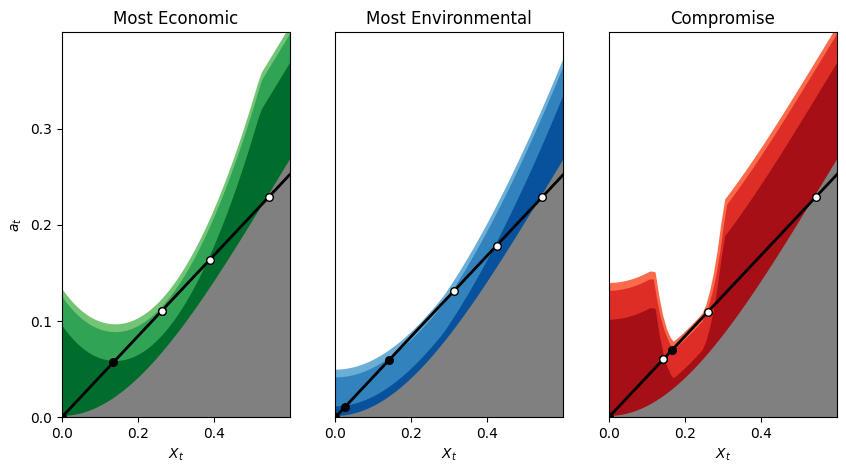

In [8]:
# get anthropogenic discharge at different lake P levels
a_bestEcon = getDischarge(bestVars[bestObj1,:], x)
a_bestP = getDischarge(bestVars[bestObj2,:],x)
a_comp = getDischarge(bestVars[bestCompromise,:],x)
a = [a_bestEcon, a_bestP, a_comp]

# get recycled P at different lake P levels
recycle = np.zeros(len(x))
for i in range(len(x)):
  recycle[i] = x[i]**q/(1+x[i]**q)

# plot equilibria under different policies
fig, axes = plt.subplots(1,3,figsize=[10,5])
for j, ax in enumerate(axes.flat):
  # plot recycled P only
  ax.plot(x, recycle, c='0.5', linewidth=2)
  ax.fill_between(x, 0, recycle, facecolor='0.5')

  # plot human inputs on top of recycled P
  ax.plot(x, recycle + a[j], c=dark_colors[j], linewidth=2)
  ax.fill_between(x, recycle, recycle + a[j], facecolor=dark_colors[j])

  # plot mean natural inputs on top of human inputs + recycled P
  ax.plot(x, recycle + a[j] + mean, c=medium_colors[j], linewidth=2)
  ax.fill_between(x, recycle + a[j], recycle + a[j] + mean, facecolor=medium_colors[j])

  # plot 99th-percentile natural inputs on top of mean natural flows + human inputs + recycled P
  ax.plot(x, recycle + a[j] + pct_99, c=light_colors[j], linewidth=2)
  ax.fill_between(x, recycle + a[j] + mean, recycle + a[j] + pct_99, facecolor=light_colors[j])

  # plot line for P sinks
  ax.plot(x, b*x, c="k", linewidth=2)

  # plot oligotrophic equilibria for 1) just recycle, 2) recycle + human, 3) recycle + human + natural mean
  ax.scatter(0, 0, facecolor="k", edgecolor="k", s=30, zorder=3)
  human_eq = root(equilibria, [0.15], args=(bestVars[bestPolicies[j],:], "human"))
  ax.scatter(human_eq.x, b*human_eq.x, facecolor="k", edgecolor="k", s=30, zorder=3)
  human_nat_eq = root(equilibria, [0.2], args=(bestVars[bestPolicies[j],:], "human+natural"))
  ax.scatter(human_nat_eq.x, b*human_nat_eq.x, facecolor="k", edgecolor="k", s=30, zorder=3)

  # find tipping point on 1) just recycle, 2) recycle + human, 3) recycle + human + natural mean
  recycle_eq = root(equilibria, 0.5, args=(recycle))
  ax.scatter(recycle_eq.x, b*recycle_eq.x, facecolor="w", edgecolor="k", s=30, zorder=3)
  human_eq = root(equilibria, [0.4], args=(bestVars[bestPolicies[j],:], "human"))
  ax.scatter(human_eq.x, b*human_eq.x, facecolor="w", edgecolor="k", s=30, zorder=3)
  human_nat_eq = root(equilibria, [0.4], args=(bestVars[bestPolicies[j],:], "human+natural"))
  ax.scatter(human_nat_eq.x, b*human_nat_eq.x, facecolor="w", edgecolor="k", s=30, zorder=3)

  # zoom in on safe operating space
  ax.set_xlim(0, 0.6)
  ax.set_ylim(0, 0.4)
  ax.set_xticks(np.arange(0,0.6,0.2))

  # labels
  ax.set_xlabel(r"$X_t$")
  ax.set_title(labels[j])
  if j == 0:
    ax.set_ylabel(r"$a_t$")
    ax.set_yticks(np.arange(0,0.4,0.1))
  else:
    ax.set_yticks([])

Plot simulated time series with these policies.

In [17]:
X_list = []
a_list = []
for k, policy in enumerate(bestPolicies):
  vars = bestVars[policy,:]
  X, a = LakeModel_DPS(vars, opt=False)
  X_list.append(X)
  a_list.append(a)

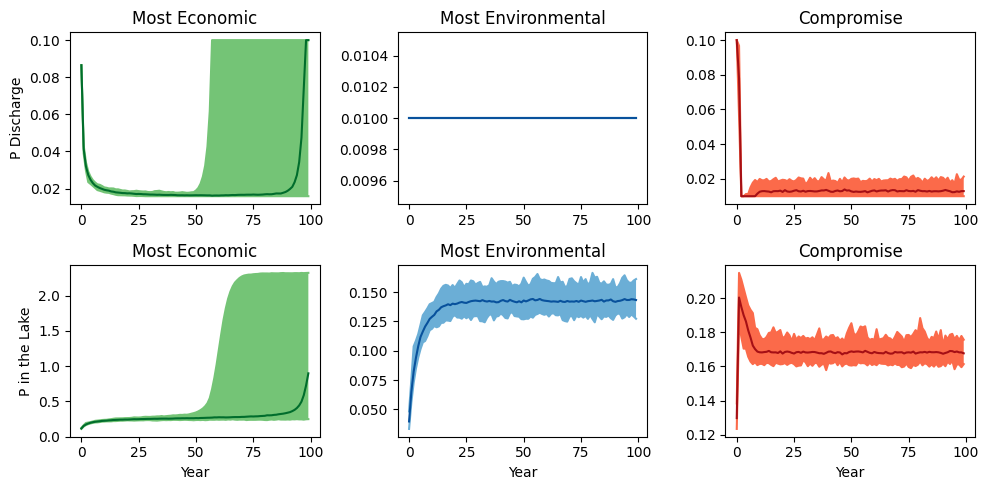

In [18]:
fig, axes = plt.subplots(2,3, figsize=[10,5])

for i, ax in enumerate(axes.flat):
  index = np.mod(i,3)
  if i < 3:
    variable = a_list[index]
  else:
    variable = X_list[index][:,1::]

  ax.plot(range(T), np.min(variable,0), color=light_colors[index]) # minimum discharge each time step
  ax.plot(range(T), np.max(variable,0), color=light_colors[index]) # maximum discharge each time step
  ax.fill_between(range(T), np.min(variable,0), np.max(variable,0), facecolor=light_colors[index])
  ax.plot(range(T), np.median(variable,0), color=dark_colors[index]) # median discharge each time step
  ax.set_title(labels[index])
  if i >= 3:
    ax.set_xlabel("Year")
  if i == 0:
    ax.set_ylabel("P Discharge")
  elif i == 3:
    ax.set_ylabel("P in the Lake")

fig.tight_layout()

In [16]:
X_list[index]

[np.float64(-1.0624811004007737), np.float64(0.4456849131297521)]